### This Notebook is used to inspect the data and understand what kind of data is stored in the different files

In [1]:
import os
import numpy as np
import torch
from scipy.io import loadmat
import yaml

monkey -> minimodel format infos

In [2]:
data = np.load("./data/monkeyv1_cadena_2019.npz")
print("monkey data: ",data.files)   # Liste aller Keys

monkey data:  ['images', 'responses', 'real_responses', 'test_images', 'test_responses', 'test_real_responses', 'train_idx', 'val_idx', 'subject_id', 'repetitions', 'image_ids']


minimodel -> experanto format infos

In [3]:
# ---- Spikes ----

data = np.load("./data/FX20_nat60k_2023_09_29.npz")
#data = np.load("FX10_nat60k_2023_05_16.npz")
print("mice spikes data: ",data.files)   # Liste aller Keys
# sp: response of each neuron to each training (/ validation) image
# xpos: x cortical postion of each neuron
# ypos: y cortical postion of each neuron
# iplane: imaging plane the neuron is from 
# ss: ???
# istim_sp: indexes of the images in the image file corresponding to the stimuli used in "sp"
# istim_ss: indexes of the test images in the image file
# ss_all: responses of each neuron to each test image (500 images) to each repeat

mice spikes data:  ['sp', 'xpos', 'ypos', 'iplane', 'ss', 'istim_sp', 'istim_ss', 'ss_all']


In [4]:
print("data['iplane']: ", type(data['iplane']), ' shape: ', data['iplane'].shape, " min: " ,data['iplane'].min(), " max: " ,data['iplane'].max())

data['iplane']:  <class 'numpy.ndarray'>  shape:  (2746,)  min:  0  max:  1


In [5]:
# ---- Images -----
mat = loadmat("./data/nat60k_text16.mat")
print(mat.keys())
print()

img = mat["img"]
istim = mat["istim"]
iorig = mat["iorig"]

print(type(img), ' img: ', img.shape, img.min(), img.max())
print(type(istim), ' istim: ', istim.shape, istim.min(), istim.max())
print(type(iorig), ' iorig: ', iorig.shape, iorig.min(), iorig.max())

istim = istim.squeeze()
iorig = iorig.squeeze()

print("istim: ", istim[:15])
print("iorig: ", iorig[:15])


dict_keys(['__header__', '__version__', '__globals__', 'img', 'istim', 'iorig'])

<class 'numpy.ndarray'>  img:  (66, 264, 68000) 0 255
<class 'numpy.ndarray'>  istim:  (1, 76800) 1.0 68000.0
<class 'numpy.ndarray'>  iorig:  (1, 68000) 1 1031
istim:  [13755. 22126. 11181. 18439.  8146. 11867.  4932. 14447.  4498. 13468.
 18991.  3845. 23236. 67995.  2095.]
iorig:  [  3 251  99 444 691 678 570 740 745 488 442 546 150 564 539]


sensorium format stuff (dont really need this. I use experanto)

In [6]:
# image stuff
data = np.load("./data/nat30k_FX20_092923/data/images/0.npy")
print("sensorium img: ", data.shape)
print()

# meta stuff (statistics)
data_all = np.load("./data/nat30k_FX20_092923/meta/statistics/images/all/std.npy")
data_frame = np.load("./data/nat30k_FX20_092923/meta/statistics/images/stimulus_frame/std.npy")

print("data all: ", data_all)
print("data frame: ",data_frame)

sensorium img:  (1, 66, 130)

data all:  60.87348
data frame:  60.87348


experanto stuff

In [7]:
def load_meta(meta_path):
    with open(meta_path) as f:
        meta = yaml.load(f, Loader=yaml.SafeLoader)
    return meta

meta_resp = load_meta("/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/test_upsampling_without_hamming_30.0Hz/dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/responses/meta.yml")

In [8]:
"""
# responses data.mem
path_to_mem = '/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/test_upsampling_without_hamming_30.0Hz/dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/responses/data.mem'

mm = np.memmap(path_to_mem,
                dtype=meta_resp["dtype"],
                mode="r",
                shape=(meta_resp["n_timestamps"], meta_resp["n_signals"]),
            )
print(mm.shape)     # n_timestamps * n_signals (226239*7863)
print()
print(type(mm), ' coords: ', mm.shape, mm.min(), mm.max())
print(mm[:10, :5])
"""

'\n# responses data.mem\npath_to_mem = \'/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/test_upsampling_without_hamming_30.0Hz/dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/responses/data.mem\'\n\nmm = np.memmap(path_to_mem,\n                dtype=meta_resp["dtype"],\n                mode="r",\n                shape=(meta_resp["n_timestamps"], meta_resp["n_signals"]),\n            )\nprint(mm.shape)     # n_timestamps * n_signals (226239*7863)\nprint()\nprint(type(mm), \' coords: \', mm.shape, mm.min(), mm.max())\nprint(mm[:10, :5])\n'

In [9]:
# response meta
path_to_coords = "/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/test_upsampling_without_hamming_30.0Hz/" \
    "dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/responses/meta/cell_motor_coordinates.npy"

coords = np.load(path_to_coords)
print(type(coords), ' coords: ', coords.shape, coords.min(), coords.max())
#print("coords example:", coords[:10])
print()


path_to_units = "/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/test_upsampling_without_hamming_30.0Hz/" \
    "dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/responses/meta/unit_ids.npy"

units = np.load(path_to_units)
print(type(units), ' units: ', units.shape, units.min(), units.max())
print("units example:", units[:20])
print()


path_to_means = "/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/test_upsampling_without_hamming_30.0Hz/" \
    "dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/responses/meta/means.npy"

means = np.load(path_to_means)
print(type(means), ' means: ', means.shape, means.min(), means.max())
print("means example:", means[0, :20])
print()


path_to_stds = "/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/test_upsampling_without_hamming_30.0Hz/" \
    "dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/responses/meta/stds.npy"

stds = np.load(path_to_stds)
print(type(stds), ' stds: ', stds.shape, stds.min(), stds.max())
print("stds example:", stds[0,:20])
print()

<class 'numpy.ndarray'>  coords:  (7863, 3) -1259 425

<class 'numpy.ndarray'>  units:  (7863,) 1 8736
units example: [ 1  3  4  6  7  8  9 10 11 12 14 15 16 17 19 20 21 22 24 25]

<class 'numpy.ndarray'>  means:  (1, 7863) 0.34729084 44.907436
means example: [1.0101055  1.3919626  1.6559083  1.2799321  0.87601894 1.3597481
 1.4360973  2.2154021  1.4847091  1.6313834  4.5415874  3.5730374
 2.2843792  5.556456   1.9431212  1.8679401  1.4543955  1.5915143
 1.6674546  1.3700268 ]

<class 'numpy.ndarray'>  stds:  (1, 7863) 1.6363426 118.30116
stds example: [ 3.6390064  4.395817   7.7685733  3.4157553  4.82132    4.2048125
  4.715402  11.372338   5.13376    7.3249125 17.757935  18.304998
  7.9372144 25.056507   7.9447684  6.451469   4.6372547  5.00186
  5.958239   4.4063673]



In [10]:
# screeen
path_to_timestamps = '/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/data/' \
    'test_upsampling_without_hamming_30.0Hz/dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/screen/timestamps.npy'

timestamps = np.load(path_to_timestamps)

print(type(timestamps), ' timestamps: ', timestamps.shape, timestamps.min(), timestamps.max())



path_to_means = "/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/" \
"data/test_upsampling_without_hamming_30.0Hz/dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/screen/meta/means.npy"

means = np.load(path_to_means)
print(type(means), ' means: ', means.shape, means.min(), means.max())
print("means example:", means[0, :20])
print()


path_to_stds = "/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/experanto/examples/" \
"data/test_upsampling_without_hamming_30.0Hz/dynamic29515-10-12-Video-021a75e56847d574b9acbcc06c675055_30hz/screen/meta/stds.npy"

stds = np.load(path_to_stds)
print(type(stds), ' stds: ', stds.shape, stds.min(), stds.max())
print("stds example:", stds[0,:20])
print()

<class 'numpy.ndarray'>  timestamps:  (219541,) 1682534581.746954 1682541909.9080796
<class 'numpy.ndarray'>  means:  (1, 1) 80.459076 80.459076
means example: [80.459076]

<class 'numpy.ndarray'>  stds:  (1, 1) 57.486748 57.486748
stds example: [57.486748]



In [11]:
import json

with open("/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/minimodel/" \
"internship/data_experanto/nat30k_L1_A5_022723_experanto/screen/combined_meta.json", "r") as f:
    meta = json.load(f)

n_test = sum(1 for v in meta.values() if v.get("tier") == "test")
n_train = sum(1 for v in meta.values() if v.get("tier") == "train")
n_val = sum(1 for v in meta.values() if v.get("tier") == "validation")

print("train:", n_train, "val:", n_val, "test:", n_test, "total:", len(meta))


train: 24779 val: 2754 test: 4907 total: 32440


Lets compare the data I get from the experanto dataloaders with the original data from in the minimodel format

In [12]:
from minimodel import data
from minimodel import model_trainer_exp

import matplotlib.pyplot as plt
from omegaconf import OmegaConf, open_dict
from experanto.datasets import ChunkDataset
from experanto.dataloaders import get_multisession_dataloader

In [13]:
# minimodel

# setup
device = torch.device('cuda')
mouse_id = 0
data_path = '../data'
np.random.seed(1)

# load images
img = data.load_images(data_path, mouse_id, file=data.img_file_name[mouse_id])

# load neurons
fname = '%s_nat60k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id)
n_stim, n_neurons = spks.shape
print("spks_rep_all: ", spks_rep_all.shape)
print("spks: ", spks.shape)
# split train and validation set
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)

# normalize data
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)


ineur = np.arange(0, n_neurons) #np.arange(0, n_neurons, 5)
spks_train = torch.from_numpy(spks[itrain][:,ineur]).to(device)
spks_val = torch.from_numpy(spks[ival][:,ineur]).to(device)

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_rep_all.shape, " with shape of a sample: ", spks_rep_all[0].shape)

img_train = torch.from_numpy(img[istim_train][itrain]).to(device).unsqueeze(1) # change :130 to 25:100 
img_val = torch.from_numpy(img[istim_train][ival]).to(device).unsqueeze(1)
img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)

print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())


raw image shape:  (68000, 66, 264)
cropped image shape:  (68000, 66, 130)
img:  (68000, 66, 130) -2.062947 2.088608 float32

loading activities from ../data/L1_A5_nat60k_2023_02_27.npz
spks_rep_all:  (500,)
spks:  (27533, 6636)

splitting training and validation set...
itrain:  (24779,)
ival:  (2754,)

normalizing neural data...
finished
spks_train:  torch.Size([24779, 6636]) tensor(0., device='cuda:0', dtype=torch.float64) tensor(58.7231, device='cuda:0', dtype=torch.float64)
spks_val:  torch.Size([2754, 6636]) tensor(0., device='cuda:0', dtype=torch.float64) tensor(49.2309, device='cuda:0', dtype=torch.float64)
spks_test:  (500,)  with shape of a sample:  (11, 6636)
img_train:  torch.Size([24779, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')
img_val:  torch.Size([2754, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')
img_test:  torch.Size([500, 1, 66, 130]) tensor(-2.0629, device='cuda:0') tensor(2.0886, device='cuda:0')


In [24]:
# --- setup ---
path_to_data = '/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/minimodel/internship/data_experanto_normalized'
data_folder = f'nat30k_{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_experanto'
data_path = os.path.join(path_to_data, data_folder)

# load configs for dataloaders
cfg_train = OmegaConf.load("./cfg_experanto/do_nothing_config.yaml")
cfg_val = OmegaConf.load("./cfg_experanto/do_nothing_config.yaml")
cfg_test = OmegaConf.load("./cfg_experanto/do_nothing_config.yaml")

cfg_train.dataset.modality_config.screen.valid_condition = {"tier": "train"}
cfg_train.dataset.out_keys.append("image_id")             # using this for debugging purposes
cfg_train.dataloader.shuffle = False                     # using this for debugging purposes

cfg_train.dataloader.drop_last = False

cfg_val.dataset.modality_config.screen.valid_condition = {"tier": "validation"}
cfg_val.dataset.out_keys.append("image_id")             # using this for debugging purposes
cfg_val.dataloader.shuffle = False                      # using this for debugging purposes
cfg_val.dataloader.drop_last = False

cfg_test.dataset.modality_config.screen.valid_condition = {"tier": "test"}
cfg_test.dataset.out_keys.append("image_id")        # I sadly need this to combine all samples with same image_id
cfg_test.dataloader.drop_last = False               # Here I dont need the batches to be the same size
cfg_test.dataloader.shuffle = False

# build dataloaders
paths = [data_path]
train_dl = get_multisession_dataloader(paths, cfg_train)
val_dl = get_multisession_dataloader(paths, cfg_val)
test_dl = get_multisession_dataloader(paths, cfg_test)
print("Loaded experanto data from: ", data_path)

if cfg_train.dataloader.drop_last:  train_dl_length = len(train_dl) * cfg_train.dataloader.batch_size
else:                               train_dl_length = model_trainer_exp.count_samples(train_dl)
if cfg_val.dataloader.drop_last:    val_dl_length = len(val_dl) * cfg_val.dataloader.batch_size
else:                               val_dl_length = model_trainer_exp.count_samples(val_dl)
if cfg_test.dataloader.drop_last:   test_dl_length = len(test_dl) * cfg_test.dataloader.batch_size
else:                               test_dl_length =model_trainer_exp.count_samples(test_dl)

print("length of train_dl: ", train_dl_length)
print("length of val_dl: ", val_dl_length)
print("length of test_dl: ", test_dl_length)


Loaded experanto data from:  /mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/minimodel/internship/data_experanto_normalized/nat30k_L1_A5_022723_experanto
length of train_dl:  24779
length of val_dl:  2754
length of test_dl:  4906


In [25]:
dataset_name, batch = next(iter(train_dl))
print(
    f"dataset: {dataset_name}",
)
for k, v in batch.items():
    # print(f"modality: {k}, shape: {v.shape}")

    print("Modality: ", k)
    if hasattr(v, "shape"):
        print("Shape:", v.shape)
    elif isinstance(v, dict):
        print("Sub-dict keys:", list(v.keys()))
    else:
        print("Type:", type(v))
    print()

# video shape: batch, times, channels, height, width
# neuronal responses: batch, times, neurons

dataset: session_0
Modality:  responses
Shape: torch.Size([16, 1, 6636])

Modality:  screen
Shape: torch.Size([16, 66, 1, 130])

Modality:  timestamps
Sub-dict keys: ['responses', 'screen']

Modality:  image_id
Shape: torch.Size([16])

Modality:  trial_idx
Shape: torch.Size([16])



Comparing the data

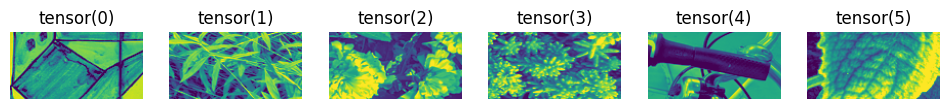

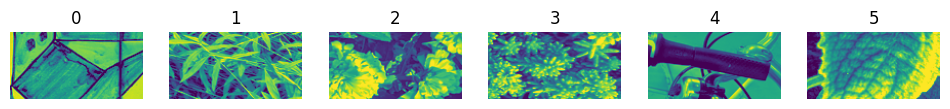

In [26]:
# compare images

fig, axs = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axs.ravel()):
    ax.set_title(batch["trial_idx"][i])
    ax.imshow(batch["screen"].squeeze()[i])  # video frames that the mouse sees
    ax.axis("off");

# 24779

plt.show()
fig, axs = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axs.ravel()):
    ax.set_title(i)
    ax.imshow(img_train.detach().cpu().squeeze()[i])  # video frames that the mouse sees
    ax.axis("off");

torch.Size([16, 1, 6636])


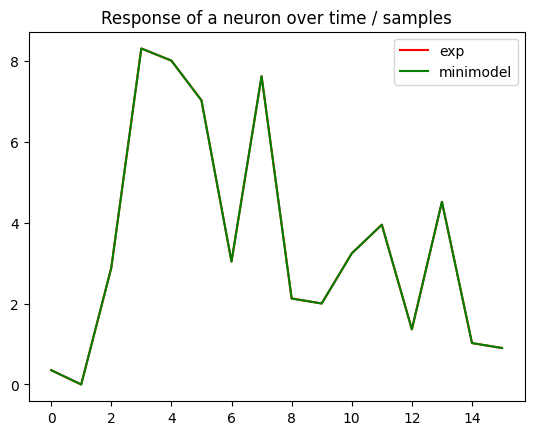

EXP:  tensor([0.3538, 0.0000, 2.8802, 8.3034, 8.0027, 7.0218, 3.0384, 7.6175, 2.1251,
        2.0012, 3.2391, 3.9481, 1.3617, 4.5148, 1.0232, 0.9005],
       dtype=torch.float64)
MINI:  tensor([0.3538, 0.0000, 2.8802, 8.3034, 8.0027, 7.0218, 3.0384, 7.6175, 2.1251,
        2.0012, 3.2391, 3.9481, 1.3617, 4.5148, 1.0232, 0.9005],
       dtype=torch.float64)


In [27]:

print(batch["responses"].shape)
plt.plot(batch["responses"][:,0,1], color="red", label="exp")
plt.plot(spks_train.detach().cpu()[:16,1], color="green", label="minimodel")
plt.title("Response of a neuron over time / samples")
plt.legend()
plt.show()
print("EXP: ", batch["responses"][:,0,1])
print("MINI: ", spks_train.detach().cpu()[:16,1])

In [18]:
paths = [data_path]
train_dl = get_multisession_dataloader(paths, cfg_train)
val_dl = get_multisession_dataloader(paths, cfg_val)
test_dl = get_multisession_dataloader(paths, cfg_test)

compare statistics:

In [19]:
batch_size = cfg_train.dataloader.batch_size

spks_train_exp = torch.zeros((train_dl_length, n_neurons), device=device)
index_array = np.arange(0, train_dl_length, batch_size)
for k , (_, batch) in zip(index_array, train_dl):
    spks_batch = batch["responses"]
    img_batch = batch["screen"]
    kend = min(k+batch_size, train_dl_length)
    spks_train_exp[k:kend] = spks_batch.squeeze()


In [20]:
# spks:
print('spks_train_exp: ', spks_train_exp.shape, spks_train_exp.min(), spks_train_exp.max())
spks_train_exp_mean = torch.mean(spks_train_exp)
spks_train_exp_std = torch.std(spks_train_exp)
print("spks_train_mean exp: ", spks_train_exp_mean.cpu().numpy())
print("spks_train_std exp: ", spks_train_exp_std.cpu().numpy())

spks_train_exp:  torch.Size([24779, 6636]) tensor(0., device='cuda:0') tensor(58.7231, device='cuda:0')
spks_train_mean exp:  0.5650235
spks_train_std exp:  1.0062783


In [21]:
# spks:
print('spks_train mini: ', spks_train.shape, spks_train.min(), spks_train.max())
mini_spks_mean = torch.mean(spks_train)
mini_spks_std = torch.std(spks_train)
print("spks_train_mean mini: ", mini_spks_mean.cpu().numpy())
print("spks_train_std mini: ", mini_spks_std.cpu().numpy())

spks_train mini:  torch.Size([24779, 6636]) tensor(0., device='cuda:0', dtype=torch.float64) tensor(58.7231, device='cuda:0', dtype=torch.float64)
spks_train_mean mini:  0.5650234749251165
spks_train_std mini:  1.0062782691984609


In [28]:
print("EXP: ", spks_train_exp[:10,1])
print("MINI: ", spks_train[:10,1])

EXP:  tensor([0.3538, 0.0000, 2.8802, 8.3034, 8.0027, 7.0218, 3.0384, 7.6175, 2.1251,
        2.0012], device='cuda:0')
MINI:  tensor([0.3538, 0.0000, 2.8802, 8.3034, 8.0027, 7.0218, 3.0384, 7.6175, 2.1251,
        2.0012], device='cuda:0', dtype=torch.float64)
